In [1]:
from mmspao.utils import *
from mmspao import mmspao
import scanpy as sc

set_random_seed(0)
device = 'cuda'


In [2]:
#Load data and perform preprocessing
rna = sc.read('/home/data1/linjing0806/multiomics/SWITCH/data/P21_brain/rna_sp.h5ad')
atac = sc.read("/home/data1/linjing0806/multiomics/SWITCH/data/P21_brain/atac_sp.h5ad")
(rna.obs_names==atac.obs_names).all()

True

In [3]:
rna.layers["counts"] = rna.X.copy()
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor="seurat_v3", layer="counts")
rna =  rna[:, rna.var['highly_variable']]

In [4]:
split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)

In [5]:
print(atac.shape[1])
sc.pp.filter_genes(atac, min_cells=atac.shape[0]*0.01)
print(atac.shape[1])
atac.layers["counts"] = atac.X.copy()
sc.pp.highly_variable_genes(atac, n_top_genes=2000, flavor="seurat_v3", layer="counts")
atac =  atac[:, atac.var['highly_variable']]

177349
136321


In [6]:
adata = rna.copy()
rna = getX(rna,modality='rna')
atac = getX(atac, modality='atac')

In [7]:
sparse = scipy.sparse.issparse(adata.X)
sparse

True

In [8]:
#if using a subset of modality-specific terms, the "sel_views" parameter should be a list with values entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features
#if using a subset of interaction terms, the "combination" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combination = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms
model = mmspao([rna,atac],sel_views='all',combination='all',sparse=True,device=device)
model.train(2500)


perform PCA for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

sparse adj for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

Training KAN for modality 1:   0%|          | 0/2500 [00:00<?, ?it/s]

Training KAN for modality 2:   0%|          | 0/2500 [00:00<?, ?it/s]

In [9]:
model.cluster(adata, n_domains=6, end=1.5)

Leiden clustering:   0%|          | 0/140 [00:00<?, ?it/s]

Found resolution: 0.78 for 6 domains


0.7799999999999997

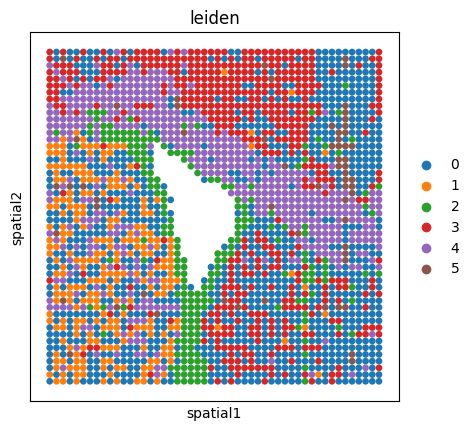

In [10]:
sc.pl.spatial(adata, color="leiden", spot_size=1, show=True)

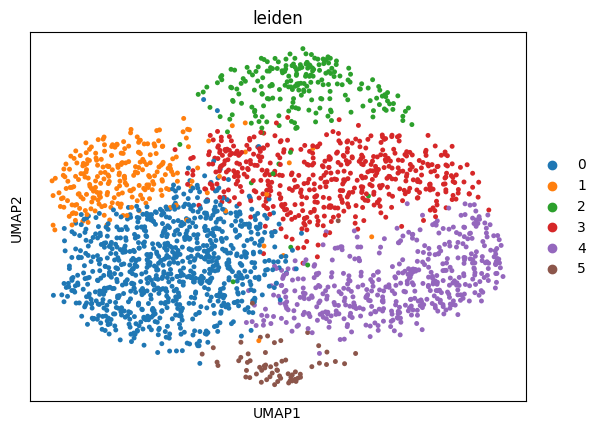

In [11]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden",)

In [12]:
{
    'Leiden modularity': model.modularity(adata), # >0.3
    "Moran's I, p_sim": model.moran(adata, k=6), # >0
    "Spatial contiguity ratio": model.contiguity(adata, k=6), # >0.5
}

{'Leiden modularity': 0.5023756453841396,
 "Moran's I, p_sim": (0.3279529634626898, 0.001),
 'Spatial contiguity ratio': 0.5025284450063211}